# Plant Disease Detection using CNN

This notebook trains a Convolutional Neural Network to classify plant leaves into three categories:
1. Healthy
2. Powdery
3. Rust

Dataset is based on leaf images. The model performs:
- Image preprocessing and augmentation
- CNN training with validation monitoring
- Evaluation using confusion matrix and classification report
- Testing with custom images

Note:
The dataset is NOT stored in this notebook. Download or mount it from Drive before running training.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!cp /content/drive/MyDrive/plantvillage-dataset.zip /content/


In [3]:
!unzip plantvillage-dataset.zip


Archive:  plantvillage-dataset.zip
  inflating: Test/Test/Healthy/8ddaa5a5caa5caa8.jpg  
  inflating: Test/Test/Healthy/8ddaac1bd6c8cd0a.jpg  
  inflating: Test/Test/Healthy/8ddd5ec1c0de38c4.jpg  
  inflating: Test/Test/Healthy/8def3f60308ab41b.jpg  
  inflating: Test/Test/Healthy/8def4d91382175c3.jpg  
  inflating: Test/Test/Healthy/8df452e2e38c0b6e.jpg  
  inflating: Test/Test/Healthy/8dfae9d78cc32089.jpg  
  inflating: Test/Test/Healthy/8e3dbccdfe08c850.jpg  
  inflating: Test/Test/Healthy/8e68163c62dc57d5.jpg  
  inflating: Test/Test/Healthy/8e6a823cce9ff40c.jpg  
  inflating: Test/Test/Healthy/8e77857194a59a87.jpg  
  inflating: Test/Test/Healthy/8e79802b3fb770c8.jpg  
  inflating: Test/Test/Healthy/8e7986d1ecd36445.jpg  
  inflating: Test/Test/Healthy/8e7e70a6878c1c79.jpg  
  inflating: Test/Test/Healthy/8e82b1a51bd11afe.jpg  
  inflating: Test/Test/Healthy/8e8470687be37378.jpg  
  inflating: Test/Test/Healthy/8e858c8397706b7b.jpg  
  inflating: Test/Test/Healthy/8e8835d2ebdbc503

In [4]:
train_dir = 'train'
val_dir = 'val'
test_dir = 'test'


Generators

In [5]:
import os
def total_files(folder_path):
    num_files = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path,f))])
    return num_files


train_file_healthy="/content/Train/Train/Healthy"
train_file_powdery="/content/Train/Train/Powdery"
train_file_rust="/content/Train/Train/Rust"

test_file_healthy="/content/Test/Test/Healthy"
test_file_powdery="/content/Test/Test/Powdery"
test_file_rust="/content/Test/Test/Rust"

validation_file_healthy="/content/Validation/Validation/Healthy"
validation_file_powdery="/content/Validation/Validation/Powdery"
validation_file_rust="/content/Validation/Validation/Rust"

print(f"Total healthy training files: {total_files(train_file_healthy)}")
print(f"Total powdery training files: {total_files(train_file_powdery)}")
print(f"Total rust training files: {total_files(train_file_rust)}")

print(f"Total healthy testing files: {total_files(test_file_healthy)}")
print(f"Total powdery testing files: {total_files(test_file_powdery)}")
print(f"Total rust testing files: {total_files(test_file_rust)}")

print(f"Total healthy validation files: {total_files(validation_file_healthy)}")
print(f"Total powdery validation files: {total_files(validation_file_powdery)}")
print(f"Total rust validation files: {total_files(validation_file_rust)}")

Total healthy training files: 458
Total powdery training files: 430
Total rust training files: 434
Total healthy testing files: 50
Total powdery testing files: 50
Total rust testing files: 50
Total healthy validation files: 20
Total powdery validation files: 20
Total rust validation files: 20


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an instance of ImageDataGenerator for training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Create an instance of ImageDataGenerator for validation and testing data without augmentation
test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("ImageDataGenerators for training and testing have been defined.")

ImageDataGenerators for training and testing have been defined.


In [7]:
train_data = train_datagen.flow_from_directory(
    '/content/Train/Train',
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_data = test_datagen.flow_from_directory(
    '/content/Validation/Validation',
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    '/content/Test/Test',
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 1322 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 150 images belonging to 3 classes.


In [8]:
print("\n--- Training Data Info ---")
print(f"Class Indices: {train_data.class_indices}")
print(f"Number of Samples: {train_data.samples}")
print(f"Number of Classes: {train_data.num_classes}")

print("\n--- Validation Data Info ---")
print(f"Class Indices: {val_data.class_indices}")
print(f"Number of Samples: {val_data.samples}")
print(f"Number of Classes: {val_data.num_classes}")

print("\n--- Testing Data Info ---")
print(f"Class Indices: {test_data.class_indices}")
print(f"Number of Samples: {test_data.samples}")
print(f"Number of Classes: {test_data.num_classes}")


--- Training Data Info ---
Class Indices: {'Healthy': 0, 'Powdery': 1, 'Rust': 2}
Number of Samples: 1322
Number of Classes: 3

--- Validation Data Info ---
Class Indices: {'Healthy': 0, 'Powdery': 1, 'Rust': 2}
Number of Samples: 60
Number of Classes: 3

--- Testing Data Info ---
Class Indices: {'Healthy': 0, 'Powdery': 1, 'Rust': 2}
Number of Samples: 150
Number of Classes: 3


In [9]:
print(train_data.class_indices)
print(val_data.class_indices)


{'Healthy': 0, 'Powdery': 1, 'Rust': 2}
{'Healthy': 0, 'Powdery': 1, 'Rust': 2}


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 1. Define a sequential Convolutional Neural Network (CNN) model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax') # 3 classes: Healthy, Powdery, Rust
])

# 2. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("Model Summary:")
model.summary()

# 3. Train the compiled model
print("\nStarting model training...")
history = model.fit(
    train_data,
    epochs=10, # You can adjust the number of epochs as needed
    validation_data=val_data
)

print("Model training completed and history saved.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,363 (56.61 MB)

 Trainable params: 14,839,363 (56.61 MB)

 Non-trainable params: 0 (0.00 B)


Starting model training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.3943 - loss: 2.1544 - val_accuracy: 0.5833 - val_loss: 0.9675
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.7220 - loss: 0.6929 - val_accuracy: 0.8667 - val_loss: 0.4207
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8605 - loss: 0.3255 - val_accuracy: 0.8000 - val_loss: 0.5615
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9145 - loss: 0.2538 - val_accuracy: 0.8833 - val_loss: 0.2685
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9281 - loss: 0.2126 - val_accuracy: 0.8000 - val_loss: 0.3569
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9383 - loss: 0.1895 - val_accuracy: 0.9167 - val_loss: 0.3004
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.9307 - loss: 0.1902 - val_accuracy: 0.7667 - val_loss: 0.6806
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9099 - loss: 0.2660 - val_accuracy: 0.8167 - val_lo

In [11]:
print("\nEvaluating model on test data...")
loss, accuracy = model.evaluate(test_data)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Evaluating model on test data...
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9099 - loss: 0.2636
Test Loss: 0.2671
Test Accuracy: 0.9067


In [12]:
print("\n--- Model Performance Summary on Test Set ---")
print(f"The trained model achieved a Test Loss of {loss:.4f} and a Test Accuracy of {accuracy:.4f} on the unseen test data. This indicates good generalization capability.")


--- Model Performance Summary on Test Set ---
The trained model achieved a Test Loss of 0.2671 and a Test Accuracy of 0.9067 on the unseen test data. This indicates good generalization capability.


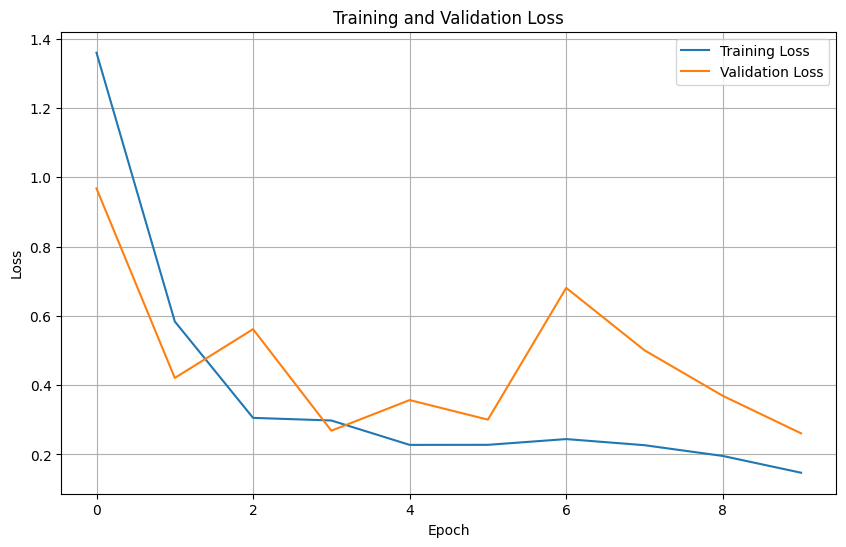

In [13]:
import matplotlib.pyplot as plt

# Plot training and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

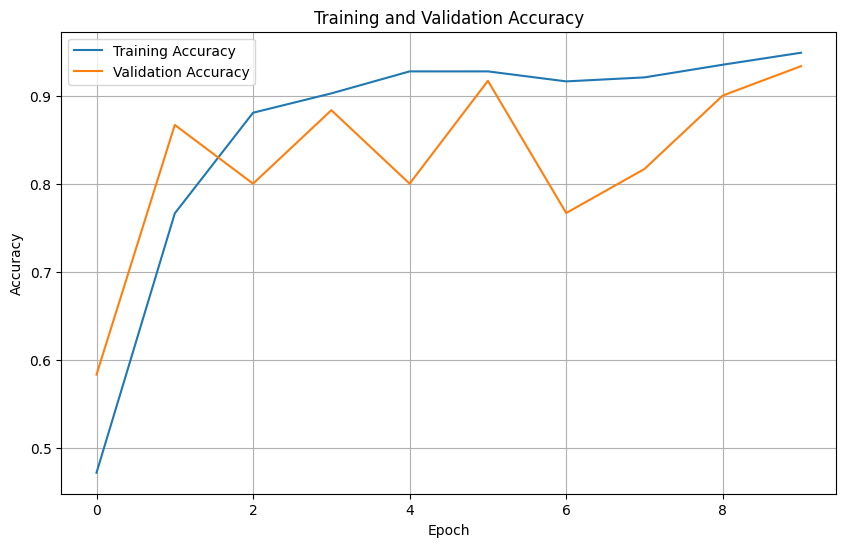

In [14]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
import numpy as np

print("Generating predictions on test data...")
y_pred = model.predict(test_data)

print("Predictions generated and stored in y_pred.")

Generating predictions on test data...
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
Predictions generated and stored in y_pred.


In [16]:
y_true = []

for i in range(len(test_data)):
    _, labels = test_data[i]
    y_true.extend(labels)

y_true = np.argmax(y_true, axis=1)

print("True labels extracted and stored in y_true.")

True labels extracted and stored in y_true.


In [17]:
from sklearn.metrics import confusion_matrix

# Convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

print("Calculating confusion matrix...")
# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

print("Confusion matrix calculated and stored in conf_matrix.")
print("\nConfusion Matrix:\n", conf_matrix)

Calculating confusion matrix...
Confusion matrix calculated and stored in conf_matrix.

Confusion Matrix:
 [[47  3  0]
 [ 5 45  0]
 [ 1  5 44]]


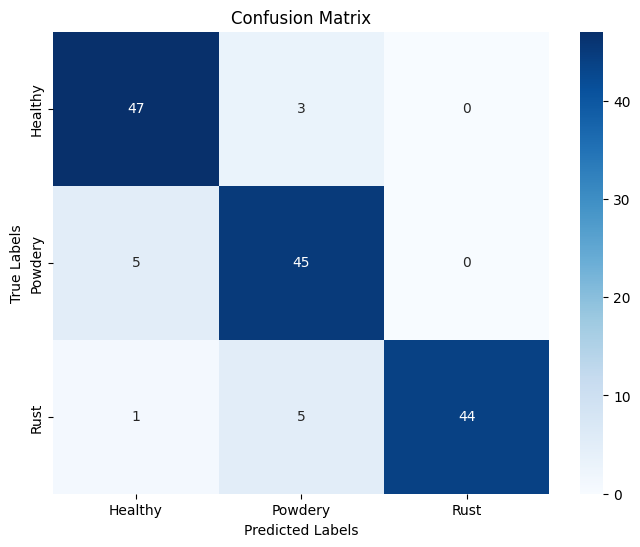

Confusion matrix heatmap displayed.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.class_indices.keys(),
            yticklabels=test_data.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

print("Confusion matrix heatmap displayed.")

Testing with custom images

In [20]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

def preprocess_image(image_path, target_size=(256, 256)):
    # load image
    img = load_img(image_path, target_size=target_size)

    # convert to array
    x = img_to_array(img)

    # scale
    x = x.astype("float32") / 255.0

    # add batch dimension
    x = np.expand_dims(x, axis=0)

    return x

# example
image_path = "/content/9e84aee68691979c.jpg"
x = preprocess_image(image_path)

# prediction




label_map = {0: "Healthy", 1: "Powdery", 2: "Rust"}

x = preprocess_image(image_path)
pred = model.predict(x)

pred_class = int(np.argmax(pred, axis=1)[0])
pred_label = label_map[pred_class]


print("Probabilities:", pred[0])

print("Predicted class:", np.argmax(pred, axis=1))

print("Predicted:", pred_label)



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step
Probabilities: [1.2070971e-04 9.9635452e-01 3.5247782e-03]
Predicted class: [1]
Predicted: Powdery
